# Regression Competition: Comparing ML Regression Algorithms

## Step1: Import Libraries and Algorithms

Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import time
import os

Import Regression algorithms

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
import xgboost as xgb

## Step 2: Kagle API setup to import "House Price" dataset

In [3]:
# Install and Upgrade Kaggle library to support new KGAT_ token format
!pip install --upgrade kaggle

# Set Kaggle API token as environment variable (get yours from kaggle.com/settings/api)
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_591c0abf794cfe4bc0ce0a7b4c27c88f' 
# You need to creat a Kaggle account, verify phone number, and accept the competion rules to be able to download the datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 3.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


# Step 3: Download dataset

In [4]:
# Download the House Prices dataset from Kaggle
!kaggle competitions download -c house-prices-advanced-regression-techniques

# Unzip the downloaded file
import zipfile
with zipfile.ZipFile('house-prices-advanced-regression-techniques.zip', 'r') as z:
    z.extractall('house_prices')

# Load the training data into a DataFrame
df = pd.read_csv('house_prices/train.csv')
print(df.shape)  # Should be (1460, 81)
df.head()

100% 199k/199k [00:00<00:00, 96.5MB/s]

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 4: EDA (Exploratory Data Analysis) and Preprocessing

First, Let's get and see the basic info: dataset's shape, type, and missing values.

In [ ]:
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nMissing values (top 10):\n", df.isnull().sum().sort_values(ascending=False))

Dataset shape: (1460, 81)

Data types:
 object     43
int64      35
float64     3
Name: count, dtype: int64

Missing values (top 10):
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


Now, Let's see the target values, i.e. house proces. 
A right-skewed distribution is common in house prices.

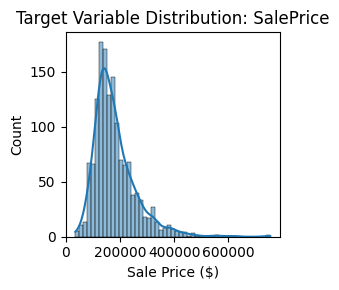

In [6]:
plt.figure(figsize=(3, 3))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Target Variable Distribution: SalePrice')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()

It is worth investigating the correlation of each features with SalePrice target value before trainng the models.
This helps to identify the most predictive features, as well as the least predictive fetures.
Let's do this via a heatmap.

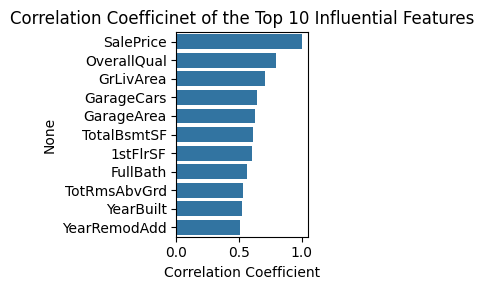

In [7]:
numerical_df = df.select_dtypes(include=[np.number])
top_corr = numerical_df.corr()['SalePrice'].sort_values(ascending=False).head(11)

plt.figure(figsize=(3, 3))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Correlation Coefficinet of the Top 10 Influential Features")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

# Step 5: Preprocessing

In this step, for simplicity, we drop the categorical data and use only the numerical data for simplicity.

The categorical data encoding, i.e. converting categorical data to numerical values, is a feature engineering practie that will be discussed later.

In [8]:
y = numerical_df['SalePrice']
X = numerical_df.drop(columns='SalePrice')

The preprocessing here includes filling the missing, i.e. null, values, splitting the data into training and test sets, and scaling the data based on the training data.

In [9]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Fill the missing values with median
# We are doing this only after splitting the data, to avoid data leakage. food for thought! 
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (1168, 37)
Test set: (292, 37)


## Step 6: Define Result Storage (a dictionary of results), and the Regression algorithms

"results" Dictionary to store performance metrics for each algorithm

In [ ]:
results = {
    'Algorithm': [],
    'RMSE': [],
    'MAE': [],
    'MSE': [],
    'R2': [],
    'Adjusted R2': [],
    'Training time': [],
    'Prediction time': []
}

"regressors" Dictionary ro store the competing regression algoritms.

In [ ]:
regressors = {
    'Linear Regression':        LinearRegression(fit_intercept=False),
    'Polynomial Regression':    Pipeline([('poly', PolynomialFeatures(degree=2)), ('linear', LinearRegression())]),
    'Ridge Regression':         Ridge(alpha=1.0),
    'Lasso Regression':         Lasso(alpha=1.0, max_iter=10000),
    'SVR':                      SVR(kernel='rbf'),
    'Decision Tree':            DecisionTreeRegressor(random_state=42),
    'Random Forest':            RandomForestRegressor(random_state=42),
    'Gradient Boosting':        GradientBoostingRegressor(random_state=42),
    'XGBoost':                  xgb.XGBRegressor(random_state=42),
    'K-Nearest Neighbours':     KNeighborsRegressor(n_neighbors=50, weights='distance')
}

# Step 7: Competition Loop - Train and Evaluate Each Regressor

In [12]:
# For each regressor, do the following
for name, reg in regressors.items():

    # Training
    start_time = time.time()
    reg.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    #Prediction
    start_time = time.time()
    y_pred = reg.predict(X_test_scaled)
    prediction_time = time.time() - start_time

    # Metrics
    n = X_train_scaled.shape[0] # Number of datapoints
    p = X_train_scaled.shape[1] # Number of features
    RMSE = root_mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    adjusted_R2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)

    # Save the outputs into the results dictionary
    results['Algorithm'].append(name)
    results['RMSE'].append(RMSE)
    results['MAE'].append(MAE)
    results['MSE'].append(MSE)
    results['R2'].append(R2)
    results['Adjusted R2'].append(adjusted_R2)
    results['Training time'].append(training_time)
    results['Prediction time'].append(prediction_time)

    # Print results
    print(f"\n{name}: ")
    print(f"RMSE: {RMSE:,.2f}")
    print(f"R2: {R2:,.2f}")
    print(f"Adjusted R2: {adjusted_R2:,.2f}")
    print(f"Training time: {training_time:,.2f}")


Linear Regression: 
RMSE: 188,942.83
R2: -3.65
Adjusted R2: -3.81
Training time: 0.02

Polynomial Regression: 
RMSE: 79,444.95
R2: 0.18
Adjusted R2: 0.15
Training time: 1.38

Ridge Regression: 
RMSE: 36,888.54
R2: 0.82
Adjusted R2: 0.82
Training time: 0.03

Lasso Regression: 
RMSE: 36,889.40
R2: 0.82
Adjusted R2: 0.82
Training time: 0.01

SVR: 
RMSE: 88,627.74
R2: -0.02
Adjusted R2: -0.06
Training time: 0.19

Decision Tree: 
RMSE: 41,431.10
R2: 0.78
Adjusted R2: 0.77
Training time: 0.05

Random Forest: 
RMSE: 29,574.92
R2: 0.89
Adjusted R2: 0.88
Training time: 2.24

Gradient Boosting: 
RMSE: 28,152.92
R2: 0.90
Adjusted R2: 0.89
Training time: 0.76

XGBoost: 
RMSE: 29,574.22
R2: 0.89
Adjusted R2: 0.88
Training time: 0.49

K-Nearest Neighbours: 
RMSE: 45,065.12
R2: 0.74
Adjusted R2: 0.73
Training time: 0.00


# Step 9: Post-processing; compiling the output and visualisation

Compile the data into a DataFrame

In [13]:
results_df = pd.DataFrame(results)
print("Results sorted by RMSE - the lower the better")
results_df.sort_values('RMSE')

Results sorted by RMSE - the lower the better


,Algorithm,RMSE,MAE,MSE,R2,Adjusted R2,Training time,Prediction time
7,Gradient Boosting,28152.918287,17503.584408,7.925868e+08,0.896668,0.893285,0.763810,0.001172
8,XGBoost,29574.218750,18407.460938,8.746344e+08,0.885972,0.882238,0.486612,0.002449
6,Random Forest,29574.919936,18136.984384,8.746759e+08,0.885966,0.882232,2.244300,0.015883
2,Ridge Regression,36888.539988,23006.563676,1.360764e+09,0.822594,0.816785,0.025264,0.000386
3,Lasso Regression,36889.397166,23014.592451,1.360828e+09,0.822585,0.816776,0.008758,0.000396
5,Decision Tree,41431.101289,27079.205479,1.716536e+09,0.776211,0.768883,0.048641,0.000766
9,K-Nearest Neighbours,45065.121746,24342.205791,2.030865e+09,0.735231,0.726561,0.001014,0.051037
1,Polynomial Regression,79444.949135,32542.476209,6.311500e+09,0.177154,0.150211,1.378031,0.005339
4,SVR,88627.739858,59514.089767,7.854876e+09,-0.024060,-0.057591,0.189891,0.047404
0,Linear Regression,188942.826902,185347.827929,3.569939e+10,-3.654221,-3.806616,0.023131,0.000438


Visualise RMSE Comparison 

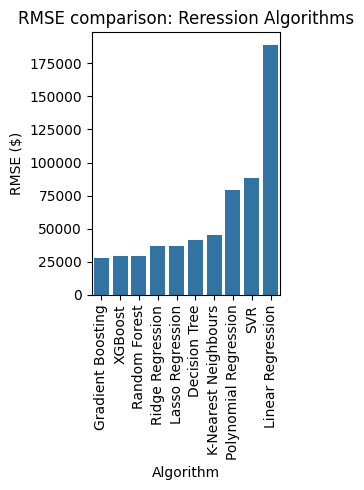

In [20]:
plt.figure(figsize=(3, 5))
sns.barplot(data=results_df.sort_values('RMSE'), x = 'Algorithm', y = 'RMSE')
plt.title('RMSE comparison: Reression Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('RMSE ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Visualise R2 comparison

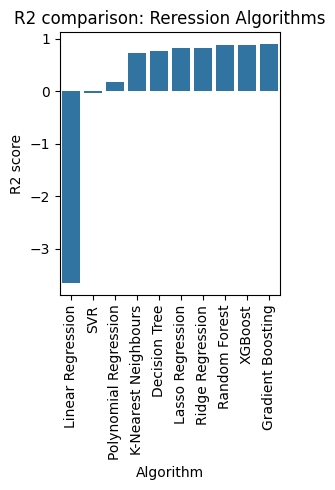

In [21]:
plt.figure(figsize=(3, 5))
sns.barplot(data=results_df.sort_values('R2'), x = 'Algorithm', y = 'R2')
plt.title('R2 comparison: Reression Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('R2 score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Visualise training time

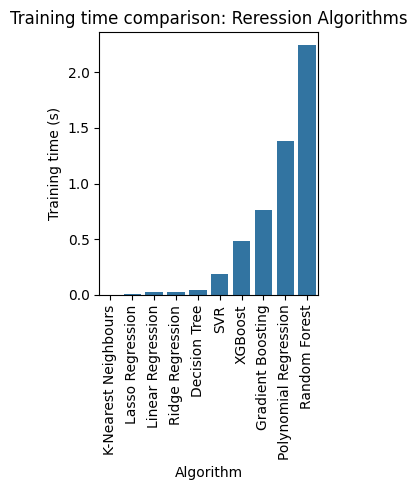

In [23]:
plt.figure(figsize=(3, 5))
sns.barplot(data=results_df.sort_values('Training time'), x = 'Algorithm', y = 'Training time')
plt.title('Training time comparison: Reression Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Training time (s)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Discussion and Conclusion:

Running the regression competition on the House Prices dataset reveals sharp performance differences — far more pronounced than in classification.
Accuracy Comparison (R²)

Gradient Boosting wins clearly (R² = 0.897, RMSE ≈ $28.2K), followed closely by XGBoost and Random Forest (R² ≈ 0.886). Ensemble methods dominate this dataset.
Ridge & Lasso Regression perform respectably (R² ≈ 0.82) — regularisation clearly helps versus plain Linear Regression.
Decision Tree and KNN lag behind the ensembles (R² 0.74–0.78), as expected from single trees and a purely distance-based method on high-dimensional data.
Polynomial Regression, SVR, and Linear Regression all underperform badly — Linear Regression is the worst, with a negative R² (-3.65), meaning it predicts worse than simply guessing the mean.

Why did Linear, Polynomial, and SVR fail?

Linear Regression is highly sensitive to multicollinearity and outliers — with ~35 unscaled-in-effect numerical features and no regularisation, coefficients likely exploded.
Polynomial Regression (degree=2) expanded the feature space massively (~35 → 600+ features), causing severe overfitting on the training set and poor generalisation.
SVR with default hyperparameters (C=1.0) is far too constrained for this scale of target values (house prices in hundreds of thousands) — it needs careful C/epsilon tuning to be competitive.

Training & Prediction Time

Fastest training: KNN, Lasso, Linear Regression (all <0.03s) — but speed didn't translate to accuracy here.
Slowest training: Gradient Boosting (0.76s) — yet it still had the best accuracy-to-time trade-off given the dataset size.
Slowest prediction: KNN (0.05s) — must compare against all training points at inference time.

Key Takeaways

Ensembles win on tabular data — Gradient Boosting, XGBoost, and Random Forest consistently outperform simpler models on structured/tabular regression problems, echoing the classification results.
Regularisation matters — Ridge/Lasso massively outperform plain Linear Regression, proving the value of penalising large coefficients on high-dimensional, correlated features.
Defaults aren't enough — SVR and Polynomial Regression aren't inherently bad; they failed here due to unt­uned hyperparameters and feature scale mismatch. This is a strong teaching moment on why hyperparameter tuning matters.
Negative R² is a red flag — it signals a fundamentally broken model for that data, not just "underperforming."

Further Work

Hyperparameter tuning (GridSearchCV/Optuna) — especially for SVR (C, epsilon, gamma) and Polynomial degree selection
Include categorical features via one-hot/target encoding (currently numerical-only)
Feature selection / dimensionality reduction (PCA) to reduce noise from 35+ features
Cross-validation instead of a single train/test split, for more reliable estimates
Log-transform SalePrice (right-skewed target) — often boosts linear model performance significantly